# Visuales para la tesis

Notebook **autocontenido**: parte únicamente de `data/raw/data.csv` (vía `build_panel`) y
genera figuras (PDF vectorial) y una tabla resumen (CSV) en `outputs/`.

**Outputs** (en `outputs/`):
- `panel_series.pdf` — 6 series macro stacked (IPC azul, resto negro, sin título).
- `forecast_univariado.pdf` — grid 2×2: AutoARIMA, AutoETS, AutoTheta, Chronos-2.
- `forecast_multivariado.pdf` — 1×2: Chronos-2 (multivariado) + VECM(r=1) sobre π.
- `forecast_covariables.pdf` — 1×2: AutoSARIMAX + Chronos-2 (covariado) con `X_lagged`.
- `tabla_resumen_long.csv` / `tabla_resumen_pi.csv` — métricas consolidadas (variable = π).

Las figuras usan `predict_all_at_last_origin` (solo el último origen). La tabla resumen
**recomputa** el backtest rolling-origin completo con `compare_models` (más costoso: ver
nota de runtime en la sección 5).

## 0 · Setup

In [1]:
import sys, warnings, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mectesis.empirical.loaders import build_panel
from mectesis.empirical.transforms import log_diff, select_optimal_lags, apply_lags
from mectesis.empirical import describe as desc
from mectesis.empirical.backtest import predict_all_at_last_origin, compare_models
from mectesis.empirical.autoselect import (
    AutoARIMAModel, AutoETSModel, AutoThetaModel, AutoSARIMAXModel,
)
from mectesis.models.var_model import VARModel, VECMModel
from mectesis.models.chronos import ChronosModel
from mectesis.models.chronos_multivariate import ChronosMultivariateModel
from mectesis.models.chronos_covariate import ChronosCovariateModel

START, END = "2016-12-01", "2026-05-01"
INITIAL_WINDOW = 72
HORIZONS = [1, 3, 6, 12]

ROOT = pathlib.Path.cwd().parent
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    # Tipografía: serif tipo Computer Modern
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
})

# Paleta: Chronos (foundation) en violeta, clásicos en azul.
CHRONOS_COLOR  = "#9672B6"
CLASSIC_COLOR  = "#4C72B0"
MODEL_COLORS = {
    "AutoARIMA":   CLASSIC_COLOR,
    "AutoETS":     CLASSIC_COLOR,
    "AutoTheta":   CLASSIC_COLOR,
    "VECM(r=1)":   CLASSIC_COLOR,
    "AutoSARIMAX": CLASSIC_COLOR,
    "Chronos-2":   CHRONOS_COLOR,
}

# Pipeline Chronos compartido entre las 3 secciones (uni, multi, cov)
chronos_pipeline = ChronosModel(device="cpu")

OUTPUT_DIR: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\dg-mectesis\outputs


In [2]:
panel = build_panel(start=START, end=END)
print(f"Panel: {panel.shape}, {panel.index.min().date()} -> {panel.index.max().date()}")
print(panel.columns.tolist())
panel.head()

Panel: (113, 6), 2016-12-01 -> 2026-04-01
['ipc', 'tpm', 'badlar', 'tcm', 'm2', 'rem']


,ipc,tpm,badlar,tcm,m2,rem
fecha,,,,,,
2016-12-01,1.2,23.1,20.0,15.8296,22.2,19.6
2017-01-01,1.3,21.8,19.8,15.9065,28.6,19.7
2017-02-01,2.5,21.0,20.1,15.5983,30.7,19.5
2017-03-01,2.4,21.5,19.5,15.5237,31.9,18.4
2017-04-01,2.6,22.6,19.2,15.3600,31.9,17.5


## 1 · Panel de series (`panel_series.pdf`)

6 series macro stacked: inflación (`ipc`) en **azul**, resto en **negro**. Sin título (va en `\caption` del .tex).

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\dg-mectesis\outputs\panel_series.pdf


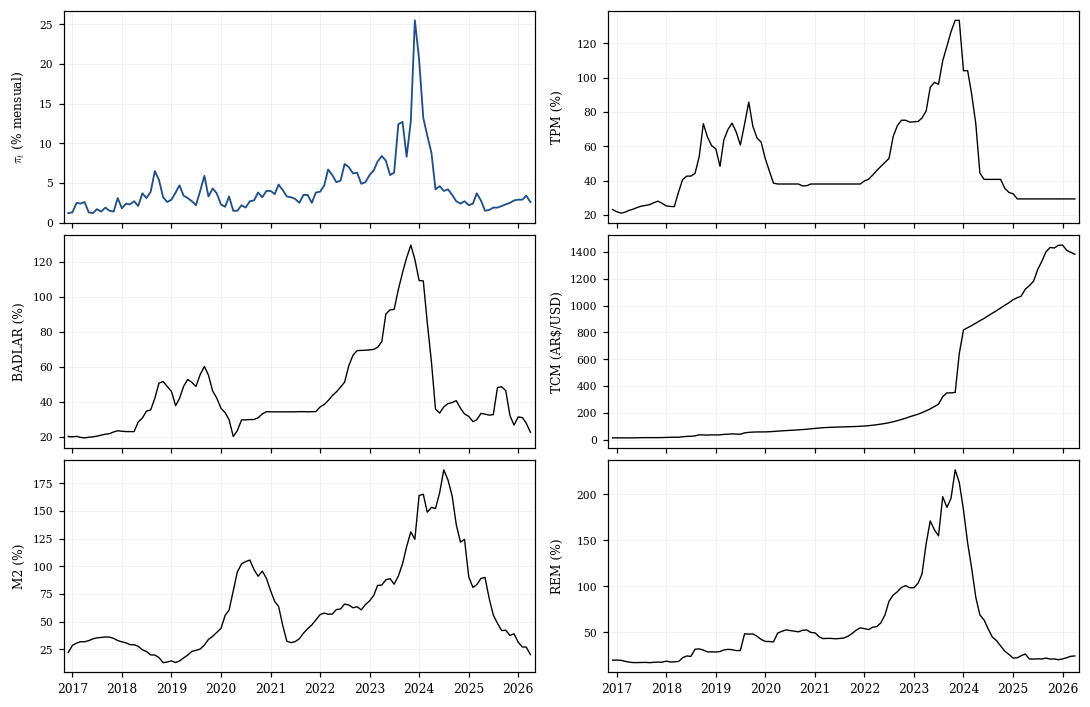

In [3]:
# Custom plot: grilla 3x2 (3 filas, 2 columnas) — 6 paneles, sin celdas vacías.
COL_ORDER = ["ipc", "tpm", "badlar", "tcm", "m2", "rem"]
LABEL_MAP = {
    "ipc":    r"$\pi_t$ (% mensual)",
    "tpm":    "TPM (%)",
    "badlar": "BADLAR (%)",
    "tcm":    "TCM (AR$/USD)",
    "m2":     "M2 (%)",
    "rem":    "REM (%)",
}

fig, axes = plt.subplots(
    nrows=3, ncols=2, sharex=True,
    figsize=(10, 6.5), constrained_layout=False,
)
axes_flat = axes.flatten()
for ax, col in zip(axes_flat, COL_ORDER):
    color = "#1f4e8c" if col == "ipc" else "k"
    lw = 1.2 if col == "ipc" else 0.9
    ax.plot(panel.index, panel[col], color=color, linewidth=lw)
    ax.set_ylabel(LABEL_MAP.get(col, col), fontsize=8)
    ax.grid(alpha=0.25, linewidth=0.4)
    ax.tick_params(axis="y", labelsize=7)
    ax.margins(x=0.01)
for ax in axes_flat[-2:]:
    ax.tick_params(axis="x", labelsize=8)
fig.align_ylabels(axes[:, 0])
fig.align_ylabels(axes[:, 1])
fig.tight_layout(h_pad=0.4, w_pad=1.0)

out = OUTPUT_DIR / "panel_series.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 2 · Forecasts univariados (`forecast_univariado.pdf`)

Grid 2×2: AutoARIMA, AutoETS, AutoTheta, Chronos-2 forecasting π en el último origen.

Origen último: t=2025-05-01, h_max=12
Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\dg-mectesis\outputs\forecast_univariado.pdf


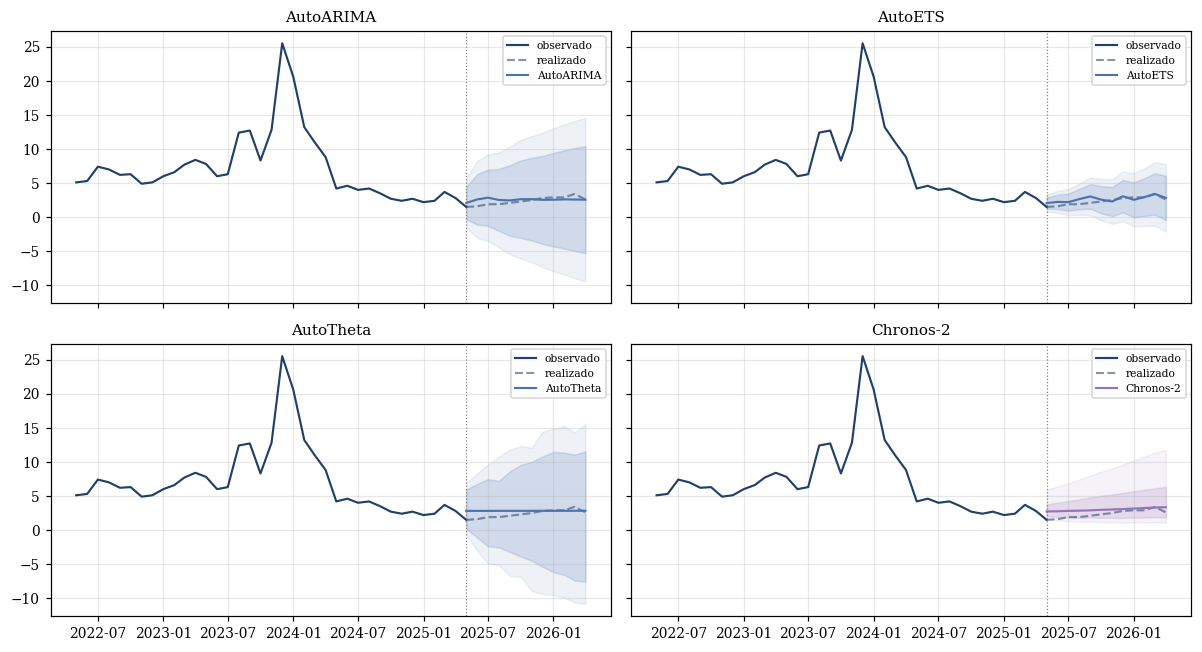

In [4]:
pi = panel["ipc"].rename("pi")

uni_factories = {
    "AutoARIMA": lambda: AutoARIMAModel(season_length=12),
    "AutoETS":   lambda: AutoETSModel(season_length=12),
    "AutoTheta": lambda: AutoThetaModel(season_length=12),
    "Chronos-2": lambda: ChronosModel(device="cpu"),
}
uni_forecasts = predict_all_at_last_origin(
    factories=uni_factories,
    y=pi, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin = uni_forecasts["AutoARIMA"]["origin_idx"]
print(f"Origen último: t={pi.index[origin].date()}, h_max={max(HORIZONS)}")

fig = desc.plot_forecast_grid(
    pi, uni_forecasts,
    origin_idx=origin, horizon=max(HORIZONS),
    ncols=2, figsize_per=(5.5, 3.0), title="",
    colors=MODEL_COLORS,
)
out = OUTPUT_DIR / "forecast_univariado.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 3 · Forecasts multivariados sobre π (`forecast_multivariado.pdf`)

1×2: **ChronosMultivariate + VECM(r=1)**. VAR(1) excluido por mala performance (RMSE h=12 = 20.22 vs ~6-8 de los otros).

Y: (112, 4), columnas: ['pi', 'dlog_tcm', 'm2', 'd_badlar']
Origen multi: t=2025-05-01
Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\dg-mectesis\outputs\forecast_multivariado.pdf


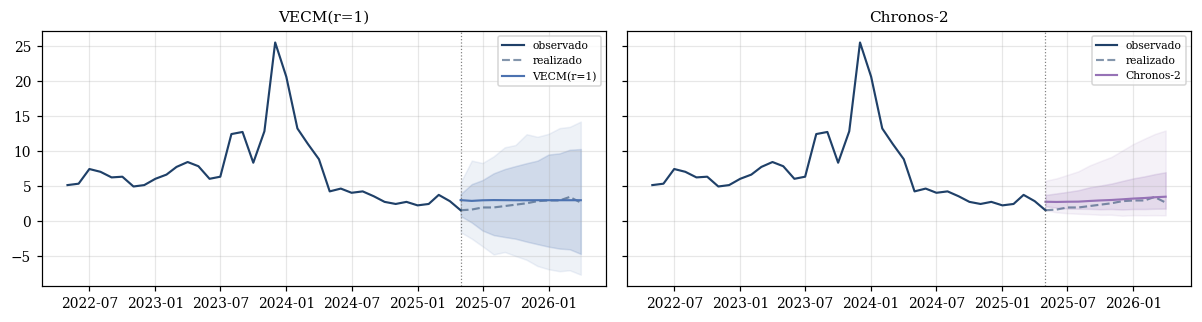

In [5]:
# Sistema endógeno (mismo que v2)
Y = pd.concat({
    "pi":       panel["ipc"],
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "m2":       panel["m2"],
    "d_badlar": panel["badlar"].diff(),
}, axis=1).dropna()
print(f"Y: {Y.shape}, columnas: {Y.columns.tolist()}")

multi_factories_visual = {
    "VECM(r=1)": lambda: VECMModel(coint_rank=1, k_ar_diff=1),
    "Chronos-2": lambda: ChronosMultivariateModel(chronos_pipeline),
}
multi_forecasts = predict_all_at_last_origin(
    factories=multi_factories_visual,
    y=Y, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin_m = multi_forecasts["VECM(r=1)"]["origin_idx"]
print(f"Origen multi: t={Y.index[origin_m].date()}")

# variable_idx=0 -> 'pi' (primera columna en Y)
fig = desc.plot_forecast_grid(
    Y["pi"], multi_forecasts,
    origin_idx=origin_m, horizon=max(HORIZONS),
    ncols=2, figsize_per=(5.5, 3.0), title="",
    variable_idx=0,
    colors=MODEL_COLORS,
)
out = OUTPUT_DIR / "forecast_multivariado.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 4 · Forecasts con covariables exógenas (`forecast_covariables.pdf`)

1×2: **AutoSARIMAX + ChronosCov** sobre π con `X_lagged` (lags óptimos data-driven, mismo procedimiento que v2 Sec. 3).


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=1.6341  , p=0.2011  , df=1
likelihood ratio test: chi2=1.6222  , p=0.2028  , df=1
parameter F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=13.6263 , p=0.0011  , df=2
likelihood ratio test: chi2=12.8461 , p=0.0016  , df=2
parameter F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=3.4353  , p=0.3292  , df=3
likelihood ratio test: chi2=3.3823  , p=0.3364  , df=3
parameter F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.2401  , p=0.2989  

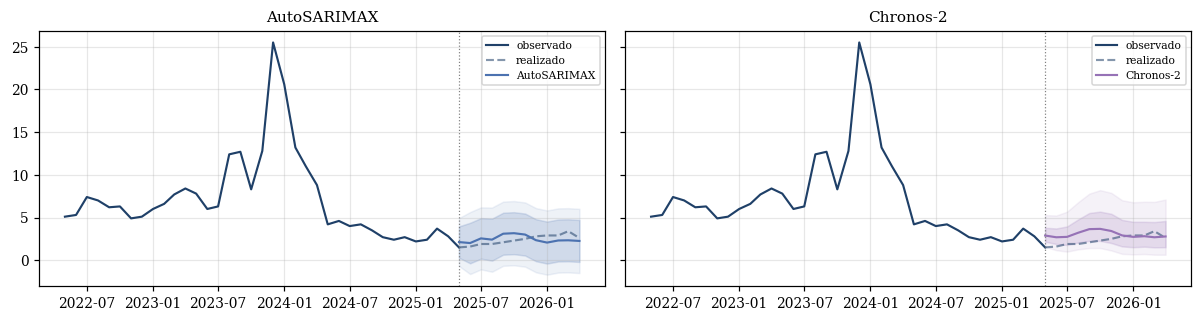

In [6]:
pi_cov = panel["ipc"].rename("pi")
X_raw = pd.concat({
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "rem":      panel["rem"],
    "badlar":   panel["badlar"],
}, axis=1).reindex(pi_cov.index).dropna()
pi_cov = pi_cov.loc[X_raw.index]
gpanel = pd.concat([pi_cov.rename("pi"), X_raw], axis=1).dropna()

lag_map = select_optimal_lags(
    y=pi_cov.rename("pi"), X=X_raw,
    max_lag=12, min_lag=1,
    granger_panel=gpanel, alpha=0.10, granger_maxlag=6,
)
print(f"lag_map: {lag_map}")

X_lagged = apply_lags(X_raw, lag_map).dropna()
pi_lag = pi_cov.loc[X_lagged.index]
print(f"X_lagged: {X_lagged.shape}, pi_lag: {pi_lag.shape}")

cov_factories = {
    "AutoSARIMAX": lambda: AutoSARIMAXModel(season_length=12),
    "Chronos-2":   lambda: ChronosCovariateModel(
        chronos_pipeline,
        n_covariates=X_lagged.shape[1],
        cov_names=list(X_lagged.columns),
    ),
}
cov_forecasts = predict_all_at_last_origin(
    factories=cov_factories,
    y=pi_lag, X=X_lagged, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin_c = cov_forecasts["AutoSARIMAX"]["origin_idx"]
print(f"Origen cov: t={pi_lag.index[origin_c].date()}")

fig = desc.plot_forecast_grid(
    pi_lag, cov_forecasts,
    origin_idx=origin_c, horizon=max(HORIZONS),
    ncols=2, figsize_per=(5.5, 3.0), title="",
    colors=MODEL_COLORS,
)
out = OUTPUT_DIR / "forecast_covariables.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 5 · Tabla resumen sobre π (`tabla_resumen_pi.csv`)

Consolidación de las 3 secciones, filtrada a `variable = π`:
- Univariado: AutoARIMA, AutoETS, AutoTheta, Chronos-2 (4 filas).
- Multivariado: VECM(r=1), Chronos-2 (2 filas; VAR(1) excluido).
- Covariables: AutoSARIMAX, Chronos-2 (2 filas).

Total: 8 filas × (4 métricas × 4 horizontes) = 8 × 16.

In [7]:
# Recompute del backtest rolling-origin para las 3 secciones, reutilizando las
# MISMAS factories definidas arriba (uni_factories, multi_factories_visual,
# cov_factories).

# 1) Univariado — y = pi
long_uni = compare_models(
    uni_factories, y=pi, horizons=HORIZONS,
    initial_window=INITIAL_WINDOW, verbose=True,
)
long_uni["seccion"] = "univariada"
long_uni["variable"] = "pi"

# 2) Multivariado — y = Y (sistema endógeno); nos quedamos con la fila de pi
long_multi = compare_models(
    multi_factories_visual, y=Y, horizons=HORIZONS,
    initial_window=INITIAL_WINDOW, verbose=True,
)
long_multi = long_multi[long_multi["variable"] == "pi"].copy()
long_multi["seccion"] = "multivariada"

# 3) Covariables — y = pi_lag, X = X_lagged
long_cov = compare_models(
    cov_factories, y=pi_lag, X=X_lagged, horizons=HORIZONS,
    initial_window=INITIAL_WINDOW, verbose=True,
)
long_cov["seccion"] = "covariadas_lagged"
long_cov["variable"] = "pi"

tabla_long = pd.concat([long_uni, long_multi, long_cov], ignore_index=True)
print(f"tabla_long: {tabla_long.shape}, columnas: {tabla_long.columns.tolist()}")

# Guardar el long
tabla_long.to_csv(OUTPUT_DIR / "tabla_resumen_long.csv", index=False)
tabla_long.head()

[backtest] AutoARIMA
[backtest] AutoETS
[backtest] AutoTheta
[backtest] Chronos-2
[backtest] VECM(r=1)
[backtest] Chronos-2
[backtest] AutoSARIMAX
[backtest] Chronos-2
tabla_long: (32, 10), columnas: ['model', 'horizon', 'n_origins', 'rmse', 'mae', 'bias', 'mase', 'crps', 'seccion', 'variable']


,model,horizon,n_origins,rmse,mae,bias,mase,crps,seccion,variable
0,AutoARIMA,1,30,3.648386,2.375470,-0.061689,1.255309,1.923596,univariada,pi
1,AutoARIMA,3,30,6.169301,4.039661,-0.551768,2.158185,3.471898,univariada,pi
2,AutoARIMA,6,30,7.464070,4.892016,-0.944543,2.702380,4.446905,univariada,pi
3,AutoARIMA,12,30,8.793635,6.314945,-2.584927,3.544448,5.722359,univariada,pi
4,AutoETS,1,30,3.644562,2.160844,-0.134437,1.186301,1.590883,univariada,pi


In [8]:
# Pivot a wide: rows=(seccion, model), cols=(metric, horizon).
# tabla_long ya está filtrado a variable = pi en las 3 secciones.
metrics = ["rmse", "mae", "crps", "mase"]
sub_long = tabla_long.melt(
    id_vars=["seccion", "model", "horizon"],
    value_vars=metrics,
    var_name="metric", value_name="value",
)
wide = sub_long.pivot_table(
    index=["seccion", "model"],
    columns=["metric", "horizon"],
    values="value",
)
# Orden de columnas: métricas en orden definido, horizontes ascendentes
wide = wide.reindex(columns=pd.MultiIndex.from_product([metrics, HORIZONS], names=["metric", "horizon"]))

# Orden de filas: secciones uni -> multi -> cov, modelos en orden lógico.
# (El modelo Chronos se llama "Chronos-2" en las 3 secciones)
section_order = ["univariada", "multivariada", "covariadas_lagged"]
model_order = {
    "univariada":        ["AutoARIMA", "AutoETS", "AutoTheta", "Chronos-2"],
    "multivariada":      ["VECM(r=1)", "Chronos-2"],
    "covariadas_lagged": ["AutoSARIMAX", "Chronos-2"],
}
ordered_idx = []
for sec in section_order:
    for m in model_order[sec]:
        if (sec, m) in wide.index:
            ordered_idx.append((sec, m))
wide = wide.loc[ordered_idx]

print(f"\nTabla resumen: {wide.shape}")
out = OUTPUT_DIR / "tabla_resumen_pi.csv"
wide.to_csv(out)
print(f"Saved: {out}")
wide.round(3)


Tabla resumen: (8, 16)
Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\dg-mectesis\outputs\tabla_resumen_pi.csv


metric                          rmse                         mae         \
horizon                           1      3      6      12     1      3    
seccion           model                                                   
univariada        AutoARIMA    3.648  6.169  7.464  8.794  2.375  4.040   
                  AutoETS      3.645  5.678  7.973  9.769  2.161  3.827   
                  AutoTheta    3.783  5.708  7.642  8.877  2.338  3.781   
                  Chronos-2    3.479  5.044  5.742  6.183  1.987  3.297   
multivariada      VECM(r=1)    3.772  5.435  7.212  8.292  2.371  3.838   
                  Chronos-2    3.802  5.184  5.866  6.142  2.229  3.449   
covariadas_lagged AutoSARIMAX  3.000  3.551  4.194  1.534  1.736  2.187   
                  Chronos-2    3.184  4.147  4.801  3.164  1.788  2.405   

metric                                        crps                       \
horizon                           6      12     1      3      6      12   
seccion           model                                                   
univariada        AutoARIMA    4.892  6.315  1.924  3.472  4.447  5.722   
                  AutoETS      5.265  7.001  1.591  2.674  3.874  4.716   
                  AutoTheta    4.812  6.108  1.967  3.192  4.239  5.344   
                  Chronos-2    3.993  4.326  1.543  2.561  3.096  3.409   
multivariada      VECM(r=1)    4.761  5.898  1.785  2.788  3.939  4.864   
                  Chronos-2    4.144  4.333  1.690  2.687  3.218  3.401   
covariadas_lagged AutoSARIMAX  2.214  1.071  1.441  1.834  1.872  0.822   
                  Chronos-2    2.667  1.898  1.408  1.884  2.136  1.403   

metric                          mase                       
horizon                           1      3      6      12  
seccion           model                                    
univariada        AutoARIMA    1.255  2.158  2.702  3.544  
                  AutoETS      1.186  2.069  2.876  3.888  
                  AutoTheta    1.275  2.052  2.665  3.457  
                  Chronos-2    1.109  1.875  2.331  2.546  
multivariada      VECM(r=1)    1.282  2.060  2.628  3.306  
                  Chronos-2    1.242  1.950  2.394  2.505  
covariadas_lagged AutoSARIMAX  0.973  1.264  1.346  0.590  
                  Chronos-2    0.996  1.400  1.619  1.118